<a href="https://colab.research.google.com/github/Artem1965/DS23_Module4_Assignment/blob/main/DS23_Module4_Assignment_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIU DS23 · Module 4 · The Pipeline Assignment · Starter Notebook
**Due August 30. Read the assignment document first, then work here.**

This notebook is scaffolding, not a solution. Your job is to build one leakage-safe
Pipeline, from raw data to model, and to JUSTIFY every decision. Remember the rubric:
**70% of the grade is on your reasoning, not on the score.** A small or even negative
lift with excellent justification beats a high score you cannot explain.

**Two tracks (pick one, see the assignment document):**
1. **Olist marketplace.** Beat the frozen benchmark you generated by running
   `DS23_Module4_Benchmark.ipynb` (it writes `module4_benchmark.json` to your Drive).
2. **Your own data.** The same process on your capstone dataset. You build your own
   minimal baseline first, then measure your lift against it.

**The one rule that never bends:** every step that learns from the data (imputation,
scaling, encoding, resampling) lives INSIDE the Pipeline, so it is fit on the training
fold only. Anything else is leakage, and leakage caps your grade.

## 0 · Setup

In [1]:
!pip install -q scikit-learn pandas numpy imbalanced-learn category_encoders

import numpy as np, pandas as pd, json
import numpy as np, pandas as pd, missingno as msno
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", None)

from google.colab import drive
drive.mount("/content/drive")
DATA_PATH = "/content/drive/My Drive/BAR ILAN/Modules/Module 1_  AI Foundations and Ethics/2. Python and SQL for Data Science/Data/Brazilian E-Commerce Public Dataset by Olist/"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 2.8 MB/s eta 0:00:00
Mounted at /content/drive


## 1 · Load the raw tables (Olist track)
For the Olist track, load the raw tables. For your own-data track, load your dataset
instead and skip to section 3.

In [2]:
items    = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
reviews  = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
orders   = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
print("tables loaded.")


tables loaded.


## 2 · The frozen benchmark
You generated this by running `DS23_Module4_Benchmark.ipynb`. Load the locked number.
Your pipeline will be measured against it. Do NOT recompute it here.

In [3]:
with open(DATA_PATH + "module4_benchmark.json") as f:
    bench = json.load(f)
print("frozen benchmark roc_auc:", bench["roc_auc"])
print("protocol:", bench["cv"], "| metric:", bench["metric"])
# If this cell errors, run DS23_Module4_Benchmark.ipynb first to create the JSON.


frozen benchmark roc_auc: 0.5586
protocol: StratifiedKFold(5, shuffle=True, random_state=42) | metric: roc_auc


## 3 · Build the modeling table
The target is a negative review (score 1 or 2). This definition is fixed for everyone,
so results are comparable. Keep the SAME row set and the SAME evaluation protocol as the
benchmark, or the comparison is not fair.

In [4]:
base = (items
        .merge(products, on="product_id", how="left")
        .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
        .merge(orders[["order_id", "order_purchase_timestamp"]], on="order_id", how="left"))
base = base.dropna(subset=["review_score"]).copy()
base["neg_review"] = (base["review_score"] <= 2).astype(int)
base["order_purchase_timestamp"] = pd.to_datetime(base["order_purchase_timestamp"])
base = base.sort_values("order_purchase_timestamp").reset_index(drop=True)
model_df = base.dropna(subset=["product_category_name"]).copy()
y = model_df["neg_review"]
print("modeling table:", model_df.shape, "| negative rate:", round(y.mean(), 4))


modeling table: (110774, 18) | negative rate: 0.1603


## 4 · The frozen evaluation protocol
Use these exact objects for every comparison. Same cv, same metric as the benchmark.

In [5]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)   # identical to the benchmark
METRIC = "roc_auc"

def evaluate(pipe, X):
    return cross_val_score(pipe, X, y, cv=cv, scoring=METRIC).mean()


---
# Your work starts here
Each section has a TODO. Fill it, and record your decision and reasoning in the
justification template (section 2 of the assignment document). One sentence of code is
not enough; the WHY is what is graded.

## 5 · Profile and handle missing values
Profile the gaps first, classify them (MCAR / MAR / MNAR), then choose an imputation
strategy. It must live inside the Pipeline.

                            n_missing  pct_missing
order_id                            0          0.0
order_item_id                       0          0.0
product_id                          0          0.0
seller_id                           0          0.0
shipping_limit_date                 0          0.0
price                               0          0.0
freight_value                       0          0.0
product_category_name               0          0.0
product_name_lenght                 0          0.0
product_description_lenght          0          0.0
product_photos_qty                  0          0.0
product_weight_g                    1          0.0
product_length_cm                   1          0.0
product_height_cm                   1          0.0
product_width_cm                    1          0.0
review_score                        0          0.0
order_purchase_timestamp            0          0.0
neg_review                          0          0.0


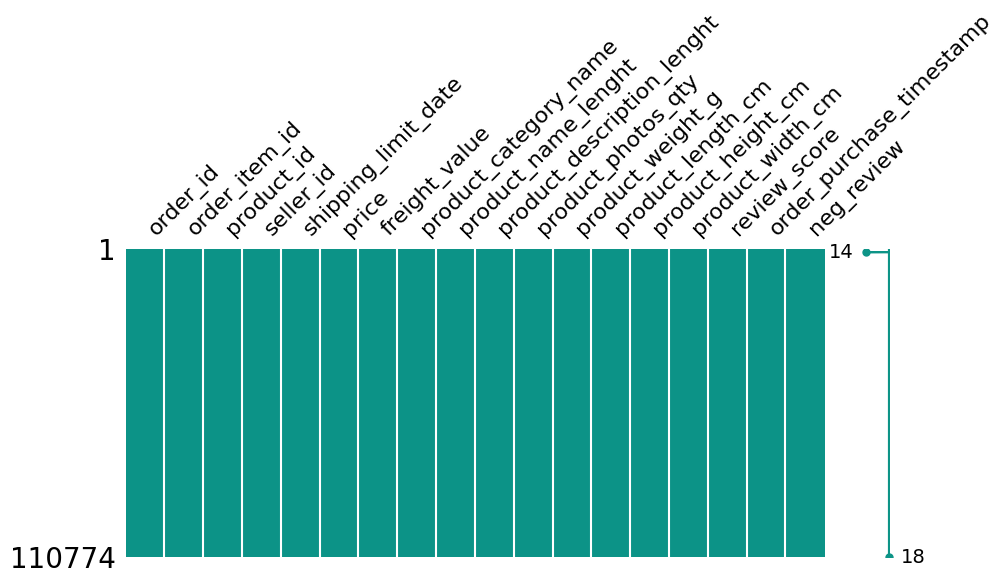

In [6]:
# TODO 5: profile missingness (counts, percentages, pattern), classify, and decide.
miss  = pd.DataFrame({"n_missing" : model_df.isna().sum(),
"pct_missing": (model_df.isna().mean() * 100).round(2),
}).sort_values("pct_missing", ascending=False)
miss.loc[miss["pct_missing"] > 0]
print(miss)
msno.matrix(model_df, figsize=(10, 4), color=(0.05, 0.58, 0.53))
plt.show()


# Record: which strategy, why, which alternative you rejected, and the evidence.

# Missingness: 4 physical-dimension columns, 1 missing value each, all in the SAME row
# (row-completeness sparkline: min=14, max=18 → one row lacks all 4 dims).
# Mechanism: NOT identifiable from a single row (MCAR/MAR/MNAR undecidable at n=1).
# Decision: median imputation inside the Pipeline — robust to any mechanism at this scale.
# Rejected: add_indicator (one row carries no predictive signal); row drop (breaks the 110,774 row-set).


In [7]:
# Confirm co-missingness: do all 4 dimension columns vanish together (block pattern)?
# NOTE: block structure shows a COMMON cause, but does NOT identify the mechanism (MCAR/MAR/MNAR).

dim_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
both_missing = model_df[dim_cols].isna().all(axis=1).sum()
any_missing  = model_df[dim_cols].isna().any(axis=1).sum()

print(f"rows where ALL four dimensions are missing: {both_missing}")
print(f"rows where ANY dimension is missing        : {any_missing}")
print("Equal counts => missing as a block (common cause). Mechanism not identifiable at this n.")

rows where ALL four dimensions are missing: 1
rows where ANY dimension is missing        : 1
Equal counts => missing as a block (common cause). Mechanism not identifiable at this n.


## 6 · Outliers
Detect outliers (IQR, Z-score, or a multivariate method), then decide: remove, clip,
transform, or keep. Justify statistically AND in business terms.

In [9]:
num_cols = [c for c in model_df.select_dtypes(include="number").columns
            if c not in ["neg_review", "review_score", "order_item_id"]]

print("Outlier detection for numeric columns:")
for col in num_cols:
    if col not in ['order_item_id']:
        q1, q3 = model_df[col].quantile([0.25, 0.75])
        iqr = q3 - q1

        iqr_mask = (model_df[col] < q1 - 1.5 * iqr) | (model_df[col] > q3 + 1.5 * iqr)
        z_mask = np.abs(stats.zscore(model_df[col].dropna())) > 3 # Dropna for zscore to avoid NaNs

        print(f"\n--- Column: {col} ---")
        print(f"IQR flags     : {iqr_mask.sum():>6} outliers ({iqr_mask.mean()*100:.2f}%")
        print(f"Z-score flags : {z_mask.sum():>6} outliers ({z_mask.mean()*100:.2f}%")


Outlier detection for numeric columns:

--- Column: price ---
IQR flags     :   8292 outliers (7.49%
Z-score flags :   1971 outliers (1.78%

--- Column: freight_value ---
IQR flags     :  11954 outliers (10.79%
Z-score flags :   2003 outliers (1.81%

--- Column: product_name_lenght ---
IQR flags     :    769 outliers (0.69%
Z-score flags :    548 outliers (0.49%

--- Column: product_description_lenght ---
IQR flags     :   6995 outliers (6.31%
Z-score flags :   2717 outliers (2.45%

--- Column: product_photos_qty ---
IQR flags     :   3060 outliers (2.76%
Z-score flags :   1562 outliers (1.41%

--- Column: product_weight_g ---
IQR flags     :  15588 outliers (14.07%
Z-score flags :   2835 outliers (2.56%

--- Column: product_length_cm ---
IQR flags     :   3566 outliers (3.22%
Z-score flags :   2170 outliers (1.96%

--- Column: product_height_cm ---
IQR flags     :   7562 outliers (6.83%
Z-score flags :   2703 outliers (2.44%

--- Column: product_width_cm ---
IQR flags     :   2531 out

In [10]:
from sklearn.preprocessing import FunctionTransformer

# 1) Skewness of ALL numeric columns - this is the selection criterion.
skew_all = model_df[num_cols].skew().sort_values(ascending=False)
print("Skewness (raw):"); print(skew_all.round(2))

# 2) Deliberate (not automatic) rule: transform only strongly skewed columns.
#    |skew| > 1 is a common cutoff for "strong" skew. Defend the threshold yourself.
SKEW_THRESHOLD = 1.0
skewed_cols = skew_all[skew_all.abs() > SKEW_THRESHOLD].index.tolist()
print("\nColumns going through log1p:", skewed_cols)

# 3) log1p: stateless -> leakage-safe by construction. All columns >= 0, so log1p is valid.
log1p_tf = FunctionTransformer(np.log1p, feature_names_out="one-to-one")

# 4) EVIDENCE (real, from your data): skew before -> after on the selected columns.
skew_after = np.log1p(model_df[skewed_cols]).skew()
print("\nlog1p effect (before -> after):")
print(pd.DataFrame({"before": skew_all[skewed_cols].round(2),
                    "after":  skew_after.round(2)}))

Skewness (raw):
price                         7.63
freight_value                 5.65
product_weight_g              3.59
product_height_cm             2.26
product_description_lenght    2.01
product_photos_qty            1.91
product_length_cm             1.76
product_width_cm              1.72
product_name_lenght          -0.91
dtype: float64

Columns going through log1p: ['price', 'freight_value', 'product_weight_g', 'product_height_cm', 'product_description_lenght', 'product_photos_qty', 'product_length_cm', 'product_width_cm']

log1p effect (before -> after):
                            before  after
price                         7.63   0.30
freight_value                 5.65  -0.00
product_weight_g              3.59   0.45
product_height_cm             2.26  -0.09
product_description_lenght    2.01  -0.16
product_photos_qty            1.91   0.94
product_length_cm             1.76   0.70
product_width_cm              1.72   0.53


## 7 · Assemble the leakage-safe Pipeline
Build a ColumnTransformer (numeric route + categorical route) and wrap it with a model.
Everything that learns from data goes inside. This skeleton is a starting point; change
the strategies to the ones YOU justified above.

In [18]:


"""
Column selection: split features into a numeric route and a categorical route.
- select_dtypes(include="number"): whitelist — takes int/float only, silently dropping
  the datetime column (would leak in as a nanosecond feature) and all object/ID columns.
- exclude neg_review: it is the label.
- exclude review_score: it is the label's SOURCE (neg_review = review_score <= 2) -> target leakage.
- exclude order_item_id: a within-order line counter, not a product property.
- cat_col: the single categorical feature, product category.
"""
num_cols = [c for c in model_df.select_dtypes(include="number").columns
            if c not in ["neg_review", "review_score", "order_item_id"]]
cat_col = "product_category_name"

"""
Numeric route: impute -> de-skew -> scale. Every step is fit on the train fold only.
- impute (median): one missing row across the four physical-dimension columns;
  median is robust to their strong right-skew.
- log1p: applied uniformly to the block. Benefit is concentrated in the strongly
  right-skewed features (price, freight, weight, dimensions), compressing the tail to
  near-symmetric (|skew| <= 1); effect on weakly-skewed features (photos, text lengths)
  is negligible. Safe for all since every value is >= 0. Stateless -> leakage-safe, no rows dropped.
- scale (StandardScaler): log1p de-skews but does not align scales across features;
  LogReg's L2 penalty punishes large-scale features unequally, so we standardize after.
  Also speeds convergence within max_iter.
"""
numeric = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log1p",  FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale",  StandardScaler()),
])

"""
Categorical route: impute -> one-hot encode. Fit on the train fold only.
- impute (constant "missing"): defensive only — rows without a category were dropped
  upstream (Section 3), so this is currently a no-op, but keeps the route robust if the
  row set ever changes.
- onehot (handle_unknown="ignore"): a category may appear in a validation fold but not
  the matching train fold; "ignore" encodes it as all-zeros instead of raising — required
  for clean CV.
"""
categorical = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

"""
Assemble the leakage-safe pipeline: route columns, then fit the frozen model.
- ColumnTransformer: sends num_cols through the numeric route and cat_col through the
  categorical route, then concatenates the outputs.
- Pipeline (pre -> model): wraps preprocessing and the model as one object, so under
  cross_val_score every learning step re-fits on each train fold -> no leakage.
"""
pre  = ColumnTransformer([("num", numeric, num_cols), ("cat", categorical, [cat_col])])
pipe = Pipeline([("pre", pre), ("model", LogisticRegression(max_iter=1000))])


In [19]:
print(num_cols)

['price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [20]:
# Naive filter — the original skeleton's trap, for comparison ONLY. Do not fit with this.
naive_cols = [c for c in model_df.columns if model_df[c].dtype != "object"
              and c not in ["neg_review", "review_score"]]

print("safe  (select_dtypes number):", len(num_cols))
print(num_cols)
print("\nnaive (!= object):", len(naive_cols))
print(naive_cols)

# What the trap lets in that the whitelist keeps out:
extra = [c for c in naive_cols if c not in num_cols]
print("\nadmitted by the trap only:", extra)
print(model_df[extra].dtypes)

safe  (select_dtypes number): 9
['price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

naive (!= object): 11
['order_item_id', 'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'order_purchase_timestamp']

admitted by the trap only: ['order_item_id', 'order_purchase_timestamp']
order_item_id                        int64
order_purchase_timestamp    datetime64[ns]
dtype: object


## 8 · Handle class imbalance
Only about one in six reviews is negative, and those are the ones that matter. Choose a
strategy (class_weight, resampling via imblearn Pipeline, or threshold tuning) and the
right metric. accuracy is not the right metric here; explain why.

In [12]:
# TODO 8: address imbalance and choose your metric. If you resample, it MUST be inside
# an imblearn Pipeline so it runs on train folds only.


## 9 · Measure your lift against the benchmark
Same cv, same metric. Report your score, the benchmark, and the lift, honestly.

In [13]:
X = model_df[num_cols + [cat_col]]
my_score = evaluate(pipe, X)
lift = my_score - bench["roc_auc"]
print(f"benchmark : {bench['roc_auc']:.4f}")
print(f"my score  : {my_score:.4f}")
print(f"my lift   : {lift:+.4f}")
# A small or negative lift is a valid result. Explain what it tells you.


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 588, in _fit
 

## 10 · Own-data track only: your own baseline
If you chose the own-data track, you have no external benchmark. Build a minimal
baseline (a simple leakage-safe pipeline on your raw features), lock its score, and
measure the lift of your cleaned and engineered pipeline against it. Same idea, same
discipline.

In [ ]:
# TODO 10 (own-data track): baseline score, then your improved score, then the lift.


---
## Before you submit
- Every learning step is inside the Pipeline (no leakage). Check twice.
- The justification template is filled for every decision: what, why, alternative
  rejected, evidence.
- Your lift is reported honestly, whatever it is.
- The notebook runs top to bottom without errors.

Good luck. The reasoning is the point.